
VIN: MB1T2VLD0spmf5089

Tank Capacity: 376


c:\Users\HTL_Sanmathi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


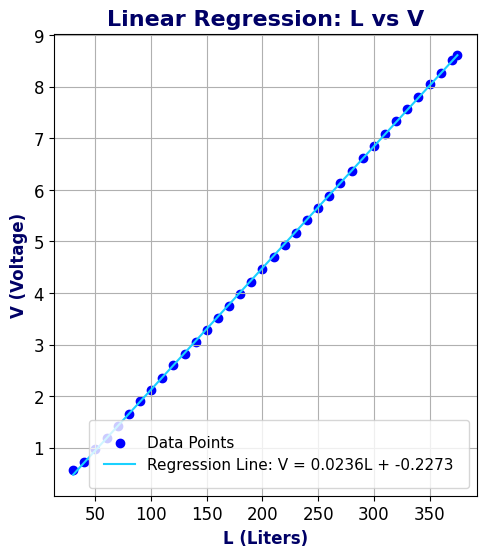

c:\Users\HTL_Sanmathi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


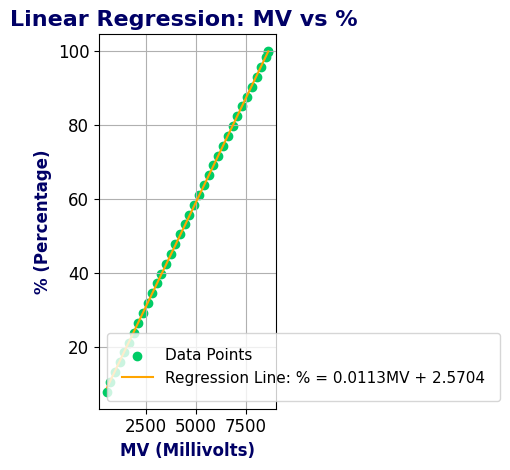

y = 0.0113MV + 2.5704
+--------------------+-----------------------+
| Description        | Value                 |
+====================+=======================+
| Regression Formula | y = 0.0113MV + 2.5704 |
+--------------------+-----------------------+
| VIN                | MB1T2VLD0spmf5089     |
+--------------------+-----------------------+
| Tank Capacity      | 376                   |
+--------------------+-----------------------+


Description,Values
VIN,MB1T2VLD0spmf5089
Formula,y = 0.0113MV + 2.5704
Tank Capacity,376


In [ ]:
# with V conversion

#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
===========================================================
Linear Regression with V Conversion
===========================================================

Author   : Sanmathi S
Year     : 2025
Version  : 1.0
Purpose  :
    This script processes tank measurement data (Liters vs Voltage),
    applies linear regression to:
        - Correct voltage values (V) based on liters (L)
        - Convert voltage to V_Conversion and millivolts (MV)
        - Calculate tank fill percentage (%)
        - Derive linear regression formula for MV vs %
    It generates regression plots and outputs results in CSV, 
    console tables, and styled HTML.

Output   :
    - CSV file with computed columns:
        L, V, V_Conversion, MV, %, linear
    - Regression plots:
        1. L vs V
        2. MV vs %
    - Console table with regression formula, VIN, and tank capacity
    - HTML table styled for presentation

Dependencies:
    - pandas
    - numpy
    - matplotlib
    - scikit-learn
    - tabulate
    - IPython.display

Usage    :
    python v_conversion_regression.py

Notes    :
    Ensure the input CSV file exists at:
    C:\Users\HTL_Sanmathi\Downloads\MB1T2VLD0spmf5089.csv
===========================================================
"""

# L,V,V_Conversion,MV,%,linear
# 0,0.5,50.0,500.0,0.0,8.061604642333691
# 30,0.57,56.99999999999999,569.9999999999999,7.772020725388601,8.866765375297113
# 40,0.72,72.0,720.0,10.362694300518134,10.592109803075877
# 50,0.91,91.0,910.0,12.953367875647666,12.77754607826231
# 60,1.13,112.99999999999999,1129.9999999999998,15.544041450777202,15.308051239004493
# 70,1.37,137.0,1370.0,18.134715025906736,18.068602323450516


import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np
from tabulate import tabulate
from IPython.display import display, HTML

# Load the CSV file

data = pd.read_csv(r"C:\Users\HTL_Sanmathi\Downloads\MB1T2VLD0spmf5089.csv")

VIN_print =data.columns.values[0]
print("\nVIN:",VIN_print)

# Dynamically rename the first two columns to 'L' and 'V'
if len(data.columns) >= 2:
    data.columns.values[0] = 'L'
    data.columns.values[1] = 'V'  


# Step 1: Filter Rows Where `V` Value Changes
data = data[data['V'].shift() != data['V']]

# Step 2: Fix the Last Row's Incorrect `V` Value
reg_L_V = LinearRegression()
filtered_data = data.iloc[1:-1]  # Exclude the first and last rows for regression
X_L = filtered_data[['L']].values
y_V = filtered_data['V'].values
reg_L_V.fit(X_L, y_V)

# Predict and fix the last row
last_row = data.iloc[-1]

corrected_V = reg_L_V.predict([[last_row['L']]])[0]
data.loc[data.index[-1], 'V'] = corrected_V

# # Step 3: Add a New Column `MV` (Millivolts)
# data['MV'] = data['V'] * 10


data['V_Conversion'] = data['V'] * 100
        
data['MV'] = data['V_Conversion'] * 10

# Step 4: Add a New Column `%` (Percentage)
max_L = data['L'].max()
print("\nTank Capacity:",max_L)

data['%'] = (data['L'] / max_L) * 100

# Step 5: Filter Rows Where `MV` Value Changes
data = data[data['MV'].shift() != data['MV']]

# Step 6: Exclude the First Row for `MV` vs `%`
data_for_regression = data.iloc[1:]  # Exclude the first row

# Perform Linear Regression for `MV vs %`
reg_MV_percent = LinearRegression()
X_MV = data_for_regression[['MV']].values  # Use data excluding the first row
y_percent = data_for_regression['%'].values
reg_MV_percent.fit(X_MV, y_percent)



# Compute Linear Regression Values for `linear` Column
m_MV = reg_MV_percent.coef_[0]  # Slope
c_MV = reg_MV_percent.intercept_  # Intercept
data['linear'] = m_MV * data['MV'] + c_MV  # Use entire `data` DataFrame

# Save the Final Output to a New CSV File
output_path = r"C:\Users\HTL_Sanmathi\Downloads\MB1T2VLD0spmf5089_output1.csv"
data.to_csv(output_path, index=False)

# Step 7: Generate and Save the Charts


# Chart 1: L vs V Linear Regression
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
predicted_V = reg_L_V.predict(filtered_data[['L']])
plt.scatter(filtered_data['L'], filtered_data['V'], color='blue', label='Data Points')
plt.plot(filtered_data['L'], predicted_V, color='#1ad1ff', label=f'Regression Line: V = {reg_L_V.coef_[0]:.4f}L + {reg_L_V.intercept_:.4f}')
plt.title('Linear Regression: L vs V',fontsize=16, color= '#000066', fontweight='bold')
plt.xlabel('L (Liters)',fontsize=12, color='#000066', fontweight='bold')
plt.ylabel('V (Voltage)',fontsize=12, color='#000066', fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=12)
plt.legend(fontsize=11, frameon=True,  borderpad=1)
plt.grid()
plt.show()

# Chart 2: MV vs % Linear Regression
plt.subplot(1, 2, 2)
predicted_percent = reg_MV_percent.predict(data_for_regression[['MV']])
plt.scatter(data_for_regression['MV'], data_for_regression['%'], color='#00cc66', label='Data Points')
plt.plot(data_for_regression['MV'], predicted_percent, color='orange', label=f'Regression Line: % = {m_MV:.4f}MV + {c_MV:.4f}')
plt.title('Linear Regression: MV vs % ',fontsize=16, color= '#000066', fontweight='bold')
plt.xlabel('MV (Millivolts)',fontsize=12, color='#000066', fontweight='bold')
plt.ylabel('% (Percentage)',fontsize=12, color='#000066', fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=12)
plt.legend(fontsize=11, frameon=True, borderpad=1)
plt.grid()

plt.tight_layout()
plt.show()


Regression_Formula=f'y = {m_MV:.4f}MV + {c_MV:.4f}'
print(Regression_Formula)

# Prepare data for the table
table_data = [
    ["Description", "Value"],
    ["Regression Formula", Regression_Formula],
    ["VIN", VIN_print],
    ["Tank Capacity", max_L]
]

# Print the table
print(tabulate(table_data, headers="firstrow", tablefmt="grid"))

# HTML and CSS for the table
html_content = f'''
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Regression Results</title>
    <style>
        body {{
            font-family: Arial, sans-serif;
            # background-color: #f4f4f4;
            margin: 0;
            padding: 20px;
        }}
        .table-container {{
            max-width: 600px;
            margin: auto;
            background: white;
            padding: 20px;
            border-radius: 8px;
            box-shadow: 0 0 10px rgba(0, 0, 0, 0.1);
        }}
        h2 {{
            text-align: center;
            color: #333;
        }}
        table {{
            width: 100%;
            border-collapse: collapse;
        }}
        th, td {{
            padding: 12px;
            text-align: left;
            border-bottom: 1px solid #ddd;
        }}
        th {{
            background-color: #007bff;
            color: white;
        }}
        tr {{
      
            color: black;
        }}
        tr:hover {{
            background-color: #f1f1f1;
        }}
    </style>
</head>
<body>
    <div class="table-container">
        <h2>Regression Results</h2>
        <table>
            <thead>
                <tr>
                    <th>Description</th>
                    <th>Values</th>
                </tr>
            </thead>
            <tbody>
                
                <tr>
                    <td>VIN</td>
                    <td>{VIN_print}</td>
                </tr>
                <tr>
                    <td>Formula</td>
                    <td>{Regression_Formula}</td>
                </tr>
                <tr>
                    <td>Tank Capacity</td>
                    <td>{max_L}</td>
                </tr>
            </tbody>
        </table>
    </div>
</body>
</html>
'''

# Display the HTML content

display(HTML(html_content))




VIN: MB1T2VLDXPPDY5552

Tank Capacity: 390


C:\Users\HTL_Sanmathi\AppData\Local\Temp\ipykernel_22128\482123758.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '856.5555555555557' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[data.index[-1], 'V'] = corrected_V
c:\Users\HTL_Sanmathi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


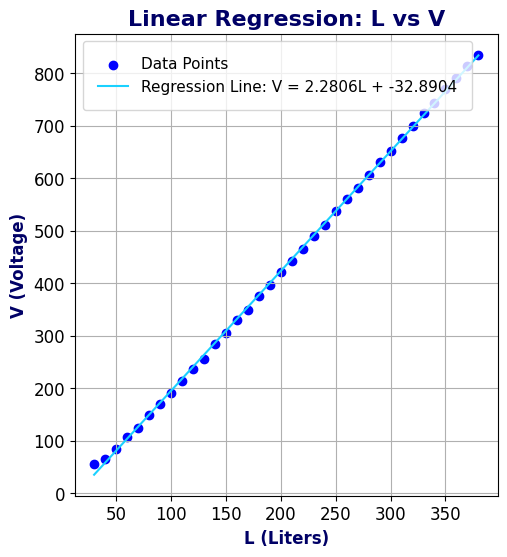

c:\Users\HTL_Sanmathi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


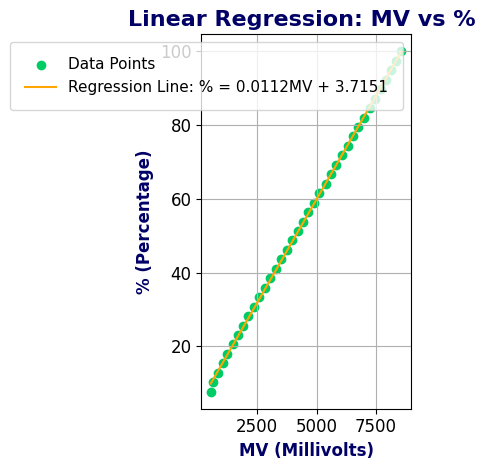

y = 0.0112MV + 3.7151
+--------------------+-----------------------+
| Description        | Value                 |
+====================+=======================+
| Regression Formula | y = 0.0112MV + 3.7151 |
+--------------------+-----------------------+
| VIN                | MB1T2VLDXPPDY5552     |
+--------------------+-----------------------+
| Tank Capacity      | 390                   |
+--------------------+-----------------------+


Description,Values
VIN,MB1T2VLDXPPDY5552
Formula,y = 0.0112MV + 3.7151
Tank Capacity,390


In [ ]:

#  without V_conversion

#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
===========================================================
Linear Regression without V Conversion
===========================================================

Author   : Sanmathi S
Year     : 2025
Version  : 1.0
Purpose  :
    This script processes tank measurement data (Liters vs Voltage),
    applies linear regression to:
        - Correct voltage values (V) based on liters (L)
        - Convert voltage to millivolts (MV)
        - Calculate tank fill percentage (%)
        - Derive linear regression formula for MV vs %
    It generates regression plots and outputs results in CSV, 
    console tables, and styled HTML.

Output   :
    - CSV file with computed columns:
        L, V, MV, %, linear
    - Regression plots:
        1. L vs V
        2. MV vs %
    - Console table with regression formula, VIN, and tank capacity
    - HTML table styled for presentation

Dependencies:
    - pandas
    - numpy
    - matplotlib
    - scikit-learn
    - tabulate
    - IPython.display

Usage    :
    python linear_regression_mv_percent.py

Notes    :
    Ensure the input CSV file exists at:
    C:\Users\HTL_Sanmathi\Downloads\MB1T2VLDXPPDY5552_LinearRegression.csv
===========================================================
"""




# MB1T2VLD4RPGC3961		in mv	in %	y = 0.0111x + 1.2845
# 0	    50	500	0	        6.8345
# 10	50	500	2.590673575	6.8345
# 20	50	500	5.18134715	6.8345
# 30	66	660	7.772020725	8.6105


import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np
from tabulate import tabulate
from IPython.display import display, HTML

# Load the CSV file

data = pd.read_csv(r"C:\Users\HTL_Sanmathi\Downloads\MB1T2VLDXPPDY5552_LinearRegression.csv")

VIN_print =data.columns.values[0]
print("\nVIN:",VIN_print)

# Dynamically rename the first two columns to 'L' and 'V'
if len(data.columns) >= 2:
    data.columns.values[0] = 'L'
    data.columns.values[1] = 'V'  


# Step 1: Filter Rows Where `V` Value Changes
data = data[data['V'].shift() != data['V']]

# Step 2: Fix the Last Row's Incorrect `V` Value
reg_L_V = LinearRegression()
filtered_data = data.iloc[1:-1]  # Exclude the first and last rows for regression
X_L = filtered_data[['L']].values
y_V = filtered_data['V'].values
reg_L_V.fit(X_L, y_V)

# Predict and fix the last row
last_row = data.iloc[-1]

corrected_V = reg_L_V.predict([[last_row['L']]])[0]
data.loc[data.index[-1], 'V'] = corrected_V

# # Step 3: Add a New Column `MV` (Millivolts)
data['MV'] = data['V'] * 10


# Step 4: Add a New Column `%` (Percentage)
max_L = data['L'].max()
print("\nTank Capacity:",max_L)

data['%'] = (data['L'] / max_L) * 100

# Step 5: Filter Rows Where `MV` Value Changes
data = data[data['MV'].shift() != data['MV']]

# Step 6: Exclude the First Row for `MV` vs `%`
data_for_regression = data.iloc[1:]  # Exclude the first row

# Perform Linear Regression for `MV vs %`
reg_MV_percent = LinearRegression()
X_MV = data_for_regression[['MV']].values  # Use data excluding the first row
y_percent = data_for_regression['%'].values
reg_MV_percent.fit(X_MV, y_percent)



# Compute Linear Regression Values for `linear` Column
m_MV = reg_MV_percent.coef_[0]  # Slope
c_MV = reg_MV_percent.intercept_  # Intercept
data['linear'] = m_MV * data['MV'] + c_MV  # Use entire `data` DataFrame

# Save the Final Output to a New CSV File
output_path = r"C:\Users\HTL_Sanmathi\Downloads\MB1T2VLDXPPDY5552_LinearRegression_output1.csv"
data.to_csv(output_path, index=False)

# Step 7: Generate and Save the Charts


# Chart 1: L vs V Linear Regression
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
predicted_V = reg_L_V.predict(filtered_data[['L']])
plt.scatter(filtered_data['L'], filtered_data['V'], color='blue', label='Data Points')
plt.plot(filtered_data['L'], predicted_V, color='#1ad1ff', label=f'Regression Line: V = {reg_L_V.coef_[0]:.4f}L + {reg_L_V.intercept_:.4f}')
plt.title('Linear Regression: L vs V',fontsize=16, color= '#000066', fontweight='bold')
plt.xlabel('L (Liters)',fontsize=12, color='#000066', fontweight='bold')
plt.ylabel('V (Voltage)',fontsize=12, color='#000066', fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=12)
plt.legend(fontsize=11, frameon=True,  borderpad=1)
plt.grid()
plt.show()

# Chart 2: MV vs % Linear Regression
plt.subplot(1, 2, 2)
predicted_percent = reg_MV_percent.predict(data_for_regression[['MV']])
plt.scatter(data_for_regression['MV'], data_for_regression['%'], color='#00cc66', label='Data Points')
plt.plot(data_for_regression['MV'], predicted_percent, color='orange', label=f'Regression Line: % = {m_MV:.4f}MV + {c_MV:.4f}')
plt.title('Linear Regression: MV vs % ',fontsize=16, color= '#000066', fontweight='bold')
plt.xlabel('MV (Millivolts)',fontsize=12, color='#000066', fontweight='bold')
plt.ylabel('% (Percentage)',fontsize=12, color='#000066', fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=12)
plt.legend(fontsize=11, frameon=True, borderpad=1)
plt.grid()

plt.tight_layout()
plt.show()


Regression_Formula=f'y = {m_MV:.4f}MV + {c_MV:.4f}'
print(Regression_Formula)

# Prepare data for the table
table_data = [
    ["Description", "Value"],
    ["Regression Formula", Regression_Formula],
    ["VIN", VIN_print],
    ["Tank Capacity", max_L]
]

# Print the table
print(tabulate(table_data, headers="firstrow", tablefmt="grid"))

# HTML and CSS for the table
html_content = f'''
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Regression Results</title>
    <style>
        body {{
            font-family: Arial, sans-serif;
            # background-color: #f4f4f4;
            margin: 0;
            padding: 20px;
        }}
        .table-container {{
            max-width: 600px;
            margin: auto;
            background: white;
            padding: 20px;
            border-radius: 8px;
            box-shadow: 0 0 10px rgba(0, 0, 0, 0.1);
        }}
        h2 {{
            text-align: center;
            color: #333;
        }}
        table {{
            width: 100%;
            border-collapse: collapse;
        }}
        th, td {{
            padding: 12px;
            text-align: left;
            border-bottom: 1px solid #ddd;
        }}
        th {{
            background-color: #007bff;
            color: white;
        }}
        tr {{
      
            color: black;
        }}
        tr:hover {{
            background-color: #f1f1f1;
        }}
    </style>
</head>
<body>
    <div class="table-container">
        <h2>Regression Results</h2>
        <table>
            <thead>
                <tr>
                    <th>Description</th>
                    <th>Values</th>
                </tr>
            </thead>
            <tbody>
                
                <tr>
                    <td>VIN</td>
                    <td>{VIN_print}</td>
                </tr>
                <tr>
                    <td>Formula</td>
                    <td>{Regression_Formula}</td>
                </tr>
                <tr>
                    <td>Tank Capacity</td>
                    <td>{max_L}</td>
                </tr>
            </tbody>
        </table>
    </div>
</body>
</html>
'''

# Display the HTML content

display(HTML(html_content))



In [5]:
! python -m  pip install pandas scikit-learn matplotlib numpy tabulate ipython



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
